# Packages

In [36]:
full_path_where_plotstyle_directory_is_located = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/plottemplate-master/low_rad_plot_style'
import sys
sys.path.append(full_path_where_plotstyle_directory_is_located)

import LowRadPlotStyle as xps
xps.use('lowrad')

In [37]:
import os
import glob
import re
from datetime import timedelta, datetime

import hist
import uproot

import dask
import awkward as ak
import dask_awkward as da
import dask.dataframe as dd
import dask_histogram as dh
from dask.diagnostics import ProgressBar

import boost_histogram as bh

from particle import Particle, ParticleNotFound

import numpy as np
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt

import pandas as pd


import time

from uncertainties import  unumpy as unp

import plotly.graph_objects as go

from iminuit import Minuit
from iminuit.cost import LeastSquares
import iminuit

In [38]:
path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/EnergyDist/Rates.npz'

rates = np.load(path, allow_pickle=True)['lin_rate']
bins = np.load(path, allow_pickle=True)['bins']
error_rates = np.load(path, allow_pickle=True)['error_lin_rate']

rates_comb = unp.uarray(rates, error_rates)

bin_breite = bins[1] - bins[0]

****
# Observing and controlling

## While sim is running

In [2]:
log_dir = "/home/b/bkoberg/logs"
err_files = glob.glob(os.path.join(log_dir, "*.err"))
non_empty_err_files = [f for f in err_files if os.path.getsize(f) > 0]

print("Nicht-leere .err Dateien:")
for f in non_empty_err_files:
    print(f)

Nicht-leere .err Dateien:
/home/b/bkoberg/logs/simulation-33337004.err
/home/b/bkoberg/logs/simulation-33337006.err
/home/b/bkoberg/logs/simulation-33337002.err
/home/b/bkoberg/logs/simulation-33337005.err
/home/b/bkoberg/logs/simulation-33357790.err
/home/b/bkoberg/logs/simulation-33336998.err
/home/b/bkoberg/logs/simulation-33337003.err


In [6]:
out_files = glob.glob(os.path.join(log_dir, "*.out"))

rows = []

for i, file in enumerate(out_files):
    with open(file, "r") as f:
        lines = f.readlines()

        perc = re.search(r"(\d+)%", lines[-1].strip())
        begin = re.search(r"(\d{4}-\d{1,2}-\d{1,2} \d{1,2}-\d{1,2}-\d{1,2})", lines[458].strip())
        now = re.search(r"(\d{4}-\d{1,2}-\d{1,2} \d{1,2}-\d{1,2}-\d{1,2})", lines[-1].strip())
        end = re.search(r"ETA: (\d{4}-\d{1,2}-\d{1,2} \d{1,2}-\d{1,2}-\d{1,2})", lines[-1].strip())

        fmt = "%Y-%m-%d %H-%M-%S"
        dt_start = datetime.strptime(begin.group(1), fmt) if begin else None
        dt_now = datetime.strptime(now.group(1), fmt) if now else None
        dt_ende = datetime.strptime(end.group(1), fmt) if end else None

        rows.append({
            "File": os.path.basename(file),
            "Progress": perc.group(1) if perc else None,
            "begin": dt_start,
            "end": dt_ende,
            "now": dt_now,
            "Time to go": (dt_ende - dt_now) if (dt_ende and dt_now) else None,
            "Total Time": (dt_ende - dt_start) if (dt_ende and dt_start) else None
        })

df = pd.DataFrame(rows)


max_time = df.loc[df["Time to go"].idxmax()]
max_total_time = df.loc[df["Total Time"].idxmax()]
print("=== MAX TIME TO GO ===")
print(max_time)
print("\n=== MAX TOTAL TIME ===")
print(max_total_time)

df_wak = df.sort_values(by="Time to go", ascending=False)
df_wak = df_wak[df_wak['Time to go'].notna()]
print("\n=== SORTED BY TIME TO GO ===")
df_wak

=== MAX TIME TO GO ===
File          simulation-33337003.out
Progress                            0
begin             2025-07-24 18:09:17
end               2025-07-25 15:28:10
now               2025-07-24 18:09:17
Time to go            0 days 21:18:53
Total Time            0 days 21:18:53
Name: 586, dtype: object

=== MAX TOTAL TIME ===
File          simulation-33337003.out
Progress                            0
begin             2025-07-24 18:09:17
end               2025-07-25 15:28:10
now               2025-07-24 18:09:17
Time to go            0 days 21:18:53
Total Time            0 days 21:18:53
Name: 586, dtype: object

=== SORTED BY TIME TO GO ===


,File,Progress,begin,end,now,Time to go,Total Time
586,simulation-33337003.out,0,2025-07-24 18:09:17,2025-07-25 15:28:10,2025-07-24 18:09:17,0 days 21:18:53,0 days 21:18:53
853,simulation-33337002.out,0,2025-07-24 18:09:08,2025-07-25 12:56:03,2025-07-24 18:11:42,0 days 18:44:21,0 days 18:46:55
470,simulation-33337005.out,0,2025-07-24 18:08:55,2025-07-25 11:27:47,2025-07-24 18:11:17,0 days 17:16:30,0 days 17:18:52
80,simulation-33337006.out,0,2025-07-24 18:08:52,2025-07-25 11:11:45,2025-07-24 18:11:11,0 days 17:00:34,0 days 17:02:53
920,simulation-33337004.out,0,2025-07-24 18:08:51,2025-07-25 10:56:13,2025-07-24 18:11:09,0 days 16:45:04,0 days 16:47:22
...,...,...,...,...,...,...,...
524,simulation-33332914.out,31,2025-07-24 13:30:09,2025-07-25 04:28:20,2025-07-24 18:10:26,0 days 10:17:54,0 days 14:58:11
265,simulation-33333104.out,31,2025-07-24 13:30:12,2025-07-25 04:28:20,2025-07-24 18:10:57,0 days 10:17:23,0 days 14:58:08
834,simulation-33333106.out,31,2025-07-24 13:30:11,2025-07-25 04:28:20,2025-07-24 18:11:37,0 days 10:16:43,0 days 14:58:09
340,simulation-33332915.out,31,2025-07-24 13:30:08,2025-07-25 04:28:20,2025-07-24 18:11:38,0 days 10:16:42,0 days 14:58:12


## After controle

In [ ]:
path_Version = "4_7e82d44"
path_Material = "Polyethylen25"  # NoAbsorber
path_length = "20cm"

# Hole alle .root-Dateien im gewünschten Verzeichnis
root_dir = f"/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/{path_Version}/{path_Material}/{path_length}"
root_files = glob.glob(os.path.join(root_dir, "*.root"))

# Lese die Dateigrößen aus und speichere sie in einer DataFrame
root_file_info = []
for file in root_files:
    size_bytes = os.path.getsize(file)
    size_mb = size_bytes / (1024 * 1024)
    root_file_info.append({
        "File": os.path.basename(file),
        "Size_MB": size_mb
    })

df_root_sizes = pd.DataFrame(root_file_info)
df_root_sizes = df_root_sizes.sort_values(by="Size_MB", ascending=False)
print(df_root_sizes)

In [12]:
log_dir = "/home/b/bkoberg/logs"
out_files = glob.glob(os.path.join(log_dir, "*.out"))

rows = []

for i, file in enumerate(out_files):
    with open(file, "r") as f:
        lines = f.readlines()

        

        exit_code_match = re.search(r"State:\s*(.*)", lines[-8].strip())
        if not exit_code_match:
            exit_code_match = re.search(r"State:\s*(.*)", lines[-9].strip())

        time_match = re.search(r"(\d{1,2}:\d{1,2}:\d{1,2})", lines[-4].strip())
        time = datetime.strptime(time_match.group(1), "%H:%M:%S") if time_match else None

        rows.append({
            "File": os.path.basename(file),
            "Exit Code": exit_code_match.group(1) if exit_code_match else None,
            "Lines": len(lines),
            "Time": time,
        })

df = pd.DataFrame(rows)

df_wak = df[df['Exit Code'] != 'COMPLETED (exit code 0)'] # either new datei or RUNNING

row_min = df.loc[df["Time"].idxmax()]
df_wak

,File,Exit Code,Lines,Time


# Things I need


## NC

### Singular no absorber

In [39]:
path_Version = "4_7e82d44"
path_Material = "NoAbsorber"  # NoAbsorber
path_length = "10cm"

print(f"Konfiguration: {path_Version}, {path_Material}, {path_length}")

path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/NC_in_LXe.npz"
grouped_index = np.load(path, allow_pickle=True)['grouped_index']
grouped_data_values = np.load(path, allow_pickle=True)['grouped_data']
laenge = np.load(path, allow_pickle=True)['laenge']
bins = np.load(path, allow_pickle=True)['bins']


histograms = {name: data for name, data in zip(grouped_index, grouped_data_values)}

Konfiguration: 4_7e82d44, NoAbsorber, 10cm


In [40]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}')

In [41]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]
edge_colors = ["#0d3b66", "#b4440e", "#1e6823", "#7c0e1e", "#5e3a8a",
        "#5d4037", "#b21d7c", "#4d4d4d", "#878d32"]

processes = ['conv', 'nCapture', 'RadioactiveDecayBase', 'xi0Inelastic', 'hadElastic', 'CoulombScat']
volumes = ['e_pri', 'Absorber', 'LXe','LXeContainer', ]
colors_process = {p: colors[i] for i, p in enumerate(processes)}
colors_Volumes = {v: edge_colors[i] for i, v in enumerate(volumes)}
colors_edges = {v: edge_colors[i] for i, v in enumerate(volumes)}

In [42]:
histograms_normalized = {key: histograms[key] / laenge for key in histograms}

# Sortiere Partikel nach Gesamtzahl der Counts (Top 5)
sorted_particles = sorted(histograms_normalized.items(), key=lambda x: x[1].sum(), reverse=True)
chosen_particles = [part for part in sorted_particles if part[0] in ['Xe137','Xe137(1)', 'Xe125','Xe125(1)']]
#chosen_particles = [part for part in sorted_particles][:5]

# Erstelle Energie-Spektren Plot

bin_centers = (bins[:-1] + bins[1:]) / 2

total_histogram = np.zeros_like(list(histograms_normalized.values())[0])
# Optional: Zeige auch die Gesamtsumme aller Partikel
total_all = sum([data.sum() for _, data in histograms_normalized.items()]) * 100
all_combined = np.zeros_like(list(histograms_normalized.values())[0])
for _, data in histograms_normalized.items():
        all_combined += data

In [43]:
# Kombiniere Histogramme für Xe137 und Xe137(1), sowie Xe125 und Xe125(1), falls beide vorhanden sind
def combine_isotopes(chosen_particles, isotope_base):
    # Finde alle passenden Einträge
    combined = None
    names = []
    for name, data in chosen_particles:
        if str(name).startswith(isotope_base):
            if combined is None:
                combined = np.copy(data)
            else:
                combined += data
            names.append(name)
    if combined is not None:
        return (isotope_base, combined)
    return None

# Beispiel für Xe137 und Xe125
combined_particles = []
for isotope in ['Xe137', 'Xe125']:
    result = combine_isotopes(chosen_particles, isotope)
    if result is not None:
        combined_particles.append(result)

# Falls du die anderen Partikel auch behalten willst:
other_particles = [(name, data) for name, data in chosen_particles if not (str(name).startswith('Xe137') or str(name).startswith('Xe125'))]
chosen_particles_combined = other_particles + combined_particles

In [44]:
[name for name, _ in chosen_particles_combined]

['Xe137', 'Xe125']

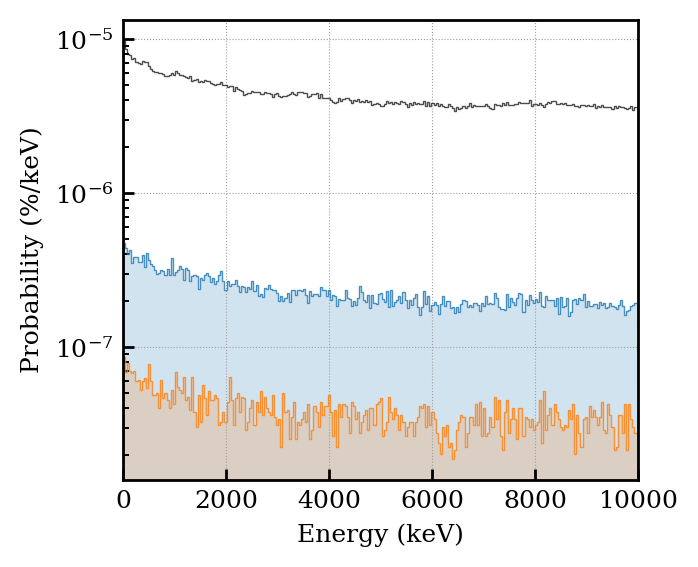


=== TOP 5 PARTIKEL ENERGIE-SPEKTREN (normiert) ===
1. Xe137          : 2.28e-05 norm. (  0.1%) - Peak bei 20 keV
2. Xe125          : 3.84e-06 norm. (  0.0%) - Peak bei 20 keV


In [45]:
plt.hist(bin_centers, bins=bins, weights=all_combined * 100 / bin_breite,
                histtype='step', color='black',
                label=f'All isotopes combined ({total_all:.4f} %)', alpha=0.7,linewidth=0.5)

# Plot der Top 5 Partikel als einzelne Spektren
for i, (particle_name, hist_vals) in enumerate(chosen_particles_combined):
        total_histogram += hist_vals

        plt.hist(bin_centers, bins=bins, weights=hist_vals*100 / bin_breite,
                        histtype='step', color=colors[i],
                        label=f'{particle_name} ({hist_vals.sum():.4f} %)', alpha=0.8,linewidth=0.5)

        plt.hist(bin_centers, bins=bins, weights=hist_vals*100 / bin_breite,
                        histtype='stepfilled', color=colors[i], alpha=0.2)


plt.xlabel('Energy (keV)')
plt.ylabel('Probability (%/keV)')
plt.yscale('log')
plt.xlim(0, 10000)
#plt.ylim(0.5 * all_combined[all_combined > 0].min(), all_combined.max() * 2)
plt.grid(True)

plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/NC_prob_noabsorber.pdf", 
                     bbox_inches='tight', dpi=300)
plt.show()

# Zusätzlich: Prozentuale Anteile der Top 5
print(f"\n=== TOP 5 PARTIKEL ENERGIE-SPEKTREN (normiert) ===")
for i, (name, data) in enumerate(chosen_particles_combined):
        percentage = (data.sum() / total_all) * 100
        peak_energy = bin_centers[np.argmax(data)]
        print(f"{i+1}. {name:15s}: {data.sum():.2e} norm. ({percentage:5.1f}%) - Peak bei {peak_energy:.0f} keV")

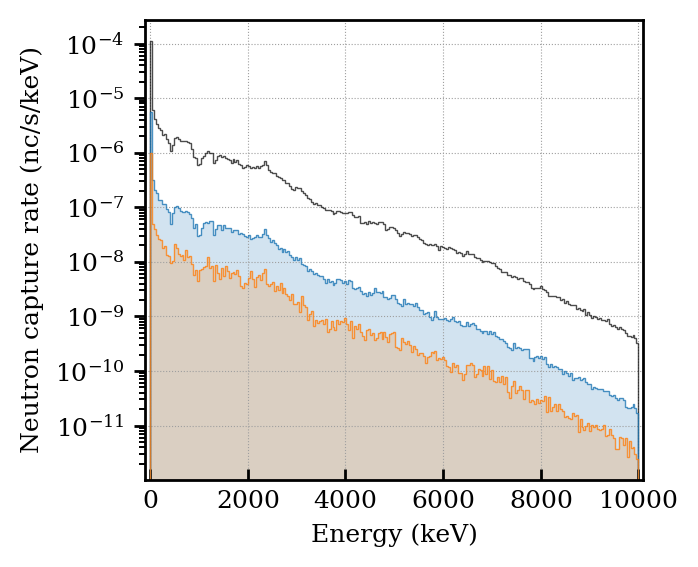


=== TOP 5 PARTIKEL ENERGIE-SPEKTREN (normiert) ===
1. Xe137          : 2.28e-05 norm. (  0.1%) - Peak bei 20 keV
2. Xe125          : 3.83e-06 norm. (  0.0%) - Peak bei 20 keV
3. Xe125(1)       : 5.55e-09 norm. (  0.0%) - Peak bei 823 keV


In [46]:
histograms_all_rates = all_combined * rates 
histograms_chosen_rates = [(name, data * rates) for name, data in chosen_particles_combined] 



plt.hist(bin_centers, bins=bins, weights=histograms_all_rates/bin_breite,
                histtype='step', color='black', alpha=0.7,linewidth=0.5)

# Plot der Top 5 Partikel als einzelne Spektren
for i, (particle_name, hist_vals) in enumerate(histograms_chosen_rates):
        total_histogram += hist_vals
        
        plt.hist(bin_centers, bins=bins, weights=hist_vals/bin_breite,
                        histtype='step', color=colors[i],
                        label=f'{particle_name} ({hist_vals.sum():.4f} %)', alpha=0.8, linewidth=0.5)

        plt.hist(bin_centers, bins=bins, weights=hist_vals/bin_breite,
                        histtype='stepfilled', color=colors[i], alpha=0.2)


plt.xlabel('Energy (keV)')
plt.ylabel('Neutron capture rate (nc/s/keV)')
plt.yscale('log')
#plt.ylim(0.5 * all_combined[all_combined > 0].min(), all_combined.max() * 2)
plt.grid(True)
b=100
plt.xlim(-b, 10000+b)
plt.tick_params(axis='y', direction='out', which='both')

plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/NC_rate_noabsorber.pdf", 
                        bbox_inches='tight', dpi=300)
plt.show()

# Zusätzlich: Prozentuale Anteile der Top 5
print(f"\n=== TOP 5 PARTIKEL ENERGIE-SPEKTREN (normiert) ===")
for i, (name, data) in enumerate(chosen_particles):
        percentage = (data.sum() / total_all) * 100
        peak_energy = bin_centers[np.argmax(data)]
        print(f"{i+1}. {name:15s}: {data.sum():.2e} norm. ({percentage:5.1f}%) - Peak bei {peak_energy:.0f} keV")

### Isotope Distribution no absorber


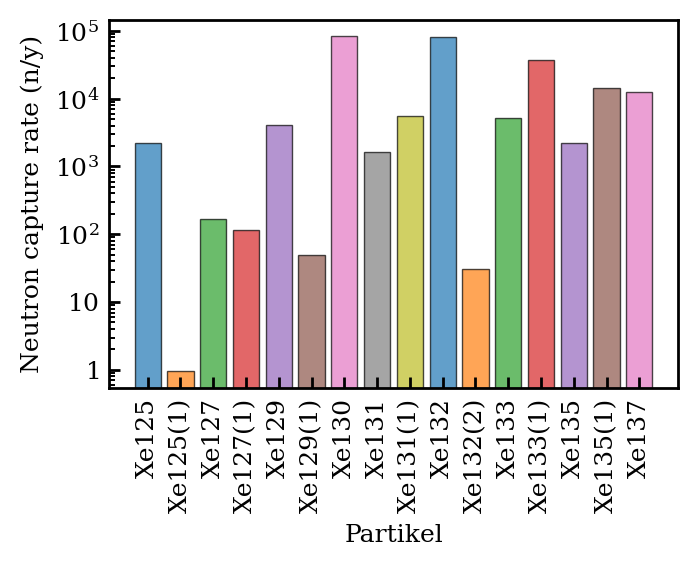

In [47]:
# Sortiere Partikel nach Gesamtzahl der Counts
histograms_normalized = {key: histograms[key] / laenge for key in histograms}
histograms_rates = {key: histograms_normalized[key] * rates for key in histograms}

sorted_particles = sorted(histograms_rates.items(), key=lambda x: x[0], reverse=False)


particle_names = [item[0] for item in sorted_particles]
total_counts = [item[1].sum() for item in sorted_particles]


# Erstelle Balkendiagramm
bars = plt.bar(
    range(len(particle_names)),
    np.array(total_counts) * 365.25 * 24 * 60 * 60, 
    color=colors[:len(particle_names)], 
    alpha=0.7,
    edgecolor='black', linewidth=0.5
)

# Formatierung
plt.xticks(
    [bar.get_x() + bar.get_width() / 2 for bar in bars],
    particle_names,
    rotation=90, ha='center'
)
plt.xlabel('Partikel')
plt.ylabel('Neutron capture rate (n/y)')
plt.yscale('log')
#plt.grid(True)

plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/NC_ParticleCounts.pdf", 
            bbox_inches='tight', dpi=300)
plt.show()


### Multiple absorber

In [48]:
path_Version = "4_7e82d44"
path_Materials = ["NoAbsorber", 'Polyethylen', 'Polyethylen25']  # NoAbsorber
path_lengths = [["10cm"], ['10cm', '20cm', '30cm', '40cm', '50cm', '60cm'], ['10cm','15cm', '20cm','25cm', '30cm','35cm', '40cm','45cm']]

paths = []
for material, lengths in zip(path_Materials, path_lengths):
    paths.append([
        f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{material}/{length}/NC_in_LXe.npz"
        for length in lengths
    ])

for absorber in paths:
    for length in absorber:
        if not os.path.exists(length):
            print(f"Fehler: Pfad {length} existiert nicht.")
            continue


Fehler: Pfad /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/Polyethylen/20cm/NC_in_LXe.npz existiert nicht.


In [51]:
grouped_index = [[None for _ in paths_list] for paths_list in paths]
grouped_data_values = [[None for _ in paths_list] for paths_list in paths]
laenge = [[None for _ in paths_list] for paths_list in paths]
bins = [[None for _ in paths_list] for paths_list in paths]
histograms = [[None for _ in paths_list] for paths_list in paths]

for i, absorber in enumerate(paths):
    for j, length in enumerate(absorber):
        path = length
        grouped_index[i][j] = np.load(path, allow_pickle=True)['grouped_index']
        grouped_data_values[i][j] = np.load(path, allow_pickle=True)['grouped_data']
        laenge[i][j] = np.load(path, allow_pickle=True)['laenge']
        bins[i][j] = np.load(path, allow_pickle=True)['bins']

        histograms[i][j] = {name: data for name, data in zip(grouped_index[i][j], grouped_data_values[i][j])}


In [52]:
for i in range(len(histograms)):
    for j in range(len(histograms[i])):
        if 'Xe125' not in histograms[i][j] or histograms[i][j]['Xe125'] is None:
            print(f"Fehler: Histogramm für Pfad {paths[i][j]} ist None oder 'Xe125' fehlt.")
            continue
        if 'Xe137' not in histograms[i][j] or histograms[i][j]['Xe137'] is None:
            print(f"Fehler: Histogramm für Pfad {paths[i][j]} ist None oder 'Xe137' fehlt.")
            continue

Fehler: Histogramm für Pfad /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/Polyethylen/60cm/NC_in_LXe.npz ist None oder 'Xe125' fehlt.


In [53]:
# kombiniert alle isotope von den jeweiligen konfigurationen
hist_comb = [[None for _ in range(len(histograms[i]))] for i in range(len(histograms))]

for i in range(len(histograms)):
    for j in range(len(histograms[i])):
        # Alle Histogramme (Werte) addieren
        all_hist = list(histograms[i][j].values())
        # Annahme: alle Histogramme sind gleich groß (z.B. 249 bins)
        hist_sum = np.sum(all_hist, axis=0)
        hist_comb[i][j] = hist_sum

hist_xe137 = [[None for _ in range(len(histograms[i]))] for i in range(len(histograms))]

for i in range(len(histograms)):
    for j in range(len(histograms[i])):
        all_hist = histograms[i][j]['Xe137'] if 'Xe137' in histograms[i][j] else np.zeros_like(histograms[i][j]['Xe132'])
        hist_xe137[i][j] = all_hist

hist_xe125 = [[None for _ in range(len(histograms[i]))] for i in range(len(histograms))]

for i in range(len(histograms)):
    for j in range(len(histograms[i])):
        all_hist = histograms[i][j]['Xe125'] if 'Xe125' in histograms[i][j] else np.zeros_like(histograms[i][j]['Xe132'])
        hist_xe125[i][j] = all_hist


In [54]:
hist_comb_err = [[None for _ in range(len(hist_comb[i]))] for i in range(len(hist_comb))]
hist_xe125_err = [[None for _ in range(len(hist_xe125[i]))] for i in range(len(hist_xe125))]
hist_xe137_err = [[None for _ in range(len(hist_xe137[i]))] for i in range(len(hist_xe137))]

for i in range(len(hist_comb)):
    for j in range(len(hist_comb[i])):
        hist_comb_err[i][j] = unp.uarray(hist_comb[i][j], np.sqrt(hist_comb[i][j]))  
        hist_xe125_err[i][j] = unp.uarray(hist_xe125[i][j], np.sqrt(hist_xe125[i][j]))
        hist_xe137_err[i][j] = unp.uarray(hist_xe137[i][j], np.sqrt(hist_xe137[i][j]))


In [55]:
# Normiert die histogramme auf die simulierte anzahl an neutronen
histograms_comb_err_normalized = [[None for _ in range(len(hist_comb_err[i]))] for i in range(len(hist_comb_err))]
histograms_xe137_err_normalized = [[None for _ in range(len(hist_xe137_err[i]))] for i in range(len(hist_xe137_err))]
histograms_xe125_err_normalized = [[None for _ in range(len(hist_xe125_err[i]))] for i in range(len(hist_xe125_err))]

for i in range(len(histograms_comb_err_normalized)):
    for j in range(len(histograms_comb_err_normalized[i])):
        histograms_comb_err_normalized[i][j] = hist_comb_err[i][j] / laenge[i][j] 

for i in range(len(histograms_xe137_err_normalized)):
    for j in range(len(histograms_xe137_err_normalized[i])):
        histograms_xe137_err_normalized[i][j] = hist_xe137_err[i][j] / laenge[i][j] 

for i in range(len(histograms_xe125_err_normalized)):
    for j in range(len(histograms_xe125_err_normalized[i])):
        histograms_xe125_err_normalized[i][j] = hist_xe125_err[i][j] / laenge[i][j] 

In [56]:
# Multipliziere alle Histogramme in histograms_comb_normalized, histograms_xe137_normalized, histograms_xe125_normalized mit rates
# Die Form der Histogramme und von rates muss passen (Anzahl der Bins)

r = rates#[3:]

histograms_comb_rate = [[None for _ in range(len(histograms_comb_err_normalized[i]))] for i in range(len(histograms_comb_err_normalized))]
histograms_xe137_rate = [[None for _ in range(len(histograms_xe137_err_normalized[i]))] for i in range(len(histograms_xe137_err_normalized))]
histograms_xe125_rate = [[None for _ in range(len(histograms_xe125_err_normalized[i]))] for i in range(len(histograms_xe125_err_normalized))]

for i in range(len(histograms_comb_err_normalized)):
    for j in range(len(histograms_comb_err_normalized[i])):
        # Prüfe, ob die Länge mit rates übereinstimmt
        if len(histograms_comb_err_normalized[i][j]) == len(r):
            histograms_comb_rate[i][j] = histograms_comb_err_normalized[i][j] * r
        else:
            histograms_comb_rate[i][j] = None  # oder np.zeros_like(histograms_comb_err_normalized[i][j])
            print(f"Fehler: Histogramm für Pfad {paths[i][j]} hat nicht die gleiche Länge wie rates. Histogramm wird auf None gesetzt.")

for i in range(len(histograms_xe137_err_normalized)):
    for j in range(len(histograms_xe137_err_normalized[i])):
        if len(histograms_xe137_err_normalized[i][j]) == len(r):
            histograms_xe137_rate[i][j] = histograms_xe137_err_normalized[i][j] * r
        else:
            histograms_xe137_rate[i][j] = None
            print(f"Fehler: Histogramm für Pfad {paths[i][j]} hat nicht die gleiche Länge wie rates. Histogramm wird auf None gesetzt.")

for i in range(len(histograms_xe125_err_normalized)):
    for j in range(len(histograms_xe125_err_normalized[i])):
        if len(histograms_xe125_err_normalized[i][j]) == len(r):
            histograms_xe125_rate[i][j] = histograms_xe125_err_normalized[i][j] * r
        else:
            histograms_xe125_rate[i][j] = None
            print(f"Fehler: Histogramm für Pfad {paths[i][j]} hat nicht die gleiche Länge wie rates. Histogramm wird auf None gesetzt.")

In [57]:
x = [[0],[10,20,30,40,50,60], [10,15,20,25,30,35,40,45]]
y_comb_rate = [[sum(histograms_comb_rate[i][j]) for j in range(len(histograms_comb_rate[i]))] for i in range(len(histograms_comb_rate))]
y_xe137_rate = [[sum(histograms_xe137_rate[i][j]) for j in range(len(histograms_xe137_rate[i]))] for i in range(len(histograms_xe137_rate))]
y_xe125_rate = [[sum(histograms_xe125_rate[i][j]) for j in range(len(histograms_xe125_rate[i]))] for i in range(len(histograms_xe125_rate))]


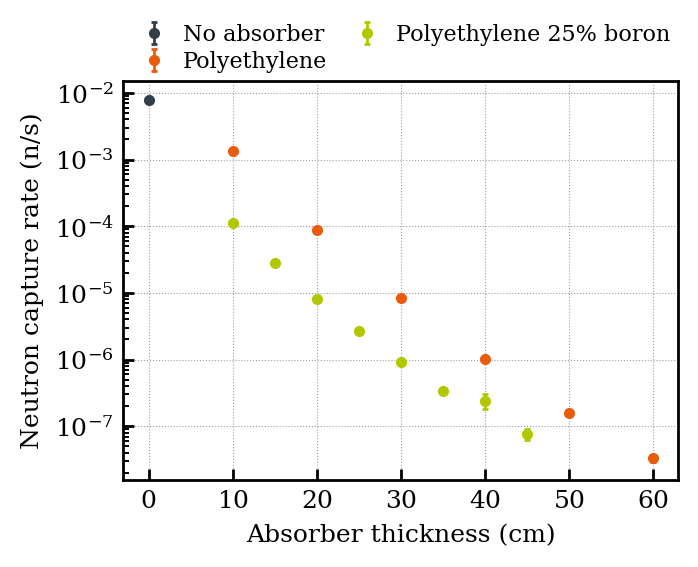

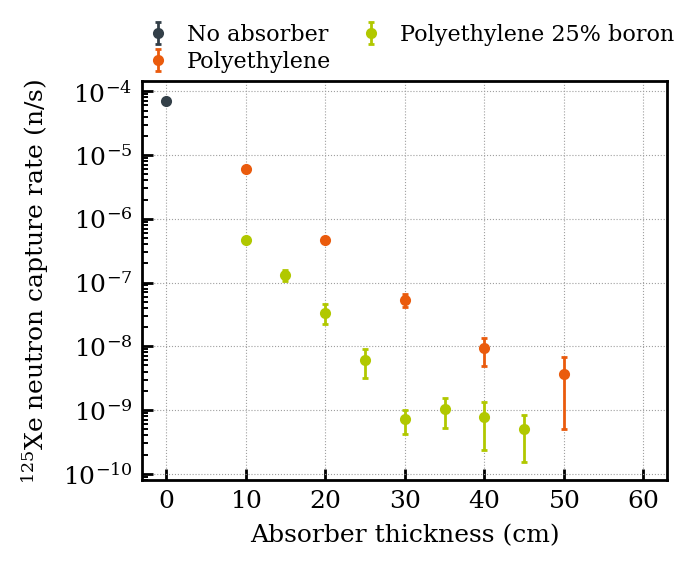

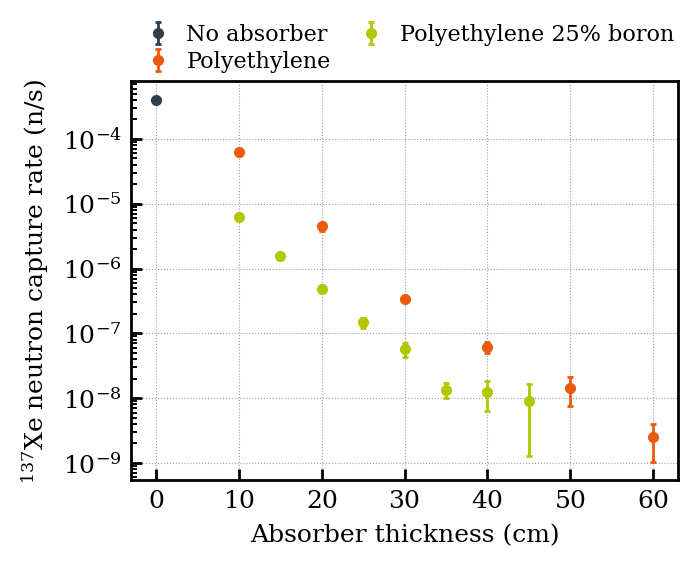

In [58]:
label = ['No absorber', 'Polyethylene', 'Polyethylene 25% boron']
yscale = [r'Neutron capture rate (n/s)', r'$^{125}$Xe neutron capture rate (n/s)',r'$^{137}$Xe neutron capture rate (n/s)']

name = ['all', 'xe125', 'xe137']

colors = [xps.colors['graphit'], xps.colors['orange'], xps.colors['peridot']]

for j,vals in enumerate([y_comb_rate,y_xe125_rate,y_xe137_rate,]):
    for i, absorber in enumerate(paths):
        plt.errorbar(x[i], unp.nominal_values(vals[i]), yerr=unp.std_devs(vals[i]),
                     fmt='o', label=f'{label[i]}', color=colors[i])


    plt.xlabel('Absorber thickness (cm)')
    plt.ylabel(f'{yscale[j]}')
    plt.yscale('log')
    plt.legend()
    plt.grid()
    plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/all/comparison_{name[j]}.pdf")
    plt.show()


In [59]:
red_10cm_poly = (1-y_comb_rate[1][0]/y_comb_rate[0][0])*100
red_10cm_poly25 = (1-y_comb_rate[2][0]/y_comb_rate[0][0])*100
red_40cm_poly = (1-y_comb_rate[1][3]/y_comb_rate[0][0])*100
red_40cm_poly25 = (1-y_comb_rate[2][6]/y_comb_rate[0][0])*100

red_10cm_poly, red_10cm_poly25, red_40cm_poly, red_40cm_poly25

(82.72350526782554+/-0.21064491146180173,
 98.60246322425003+/-0.01880067686945652,
 99.98701748477237+/-0.0005531802475452131,
 99.99692968320191+/-0.0007442572743131971)

In [60]:
rates_kg_y_1 = y_xe137_rate[0][0]*365*24*60*60/851
rates_kg_y_2 = y_xe137_rate[1][5]*365*24*60*60/851
rates_kg_y_3 = y_xe137_rate[2][5]*365*24*60*60/851
rates_kg_y_4 = y_xe137_rate[2][7]*365*24*60*60/851
rates_kg_y_1, rates_kg_y_2, rates_kg_y_3, rates_kg_y_4


(14.608792379497691+/-0.4233880848638447,
 9.302866034423757e-05+/-5.4794376251314e-05,
 0.0004974151249331728+/-0.0001284905572410181,
 0.0003337349480153702+/-0.0002857447833479497)

In [61]:
rates_kg_y_1 = y_xe125_rate[0][0]*365*24*60*60/851
rates_kg_y_2 = y_xe125_rate[1][5]*365*24*60*60/851
rates_kg_y_3 = y_xe125_rate[2][5]*365*24*60*60/851
rates_kg_y_4 = y_xe125_rate[2][7]*365*24*60*60/851

rates_kg_y_1, rates_kg_y_2, rates_kg_y_3, rates_kg_y_4

(2.5691331930723336+/-0.18147368500001937,
 0.0+/-0,
 3.829612666492984e-05+/-1.917432629579642e-05,
 1.846191550572829e-05+/-1.2798037798876766e-05)

#### Anteile

In [155]:
null_port = histograms_comb_rate[0][0] / histograms_comb_rate[0][0] 
# norm_fak = np.sum(null_port)
# null_port = null_port / norm_fak

poly_port = [rate/histograms_comb_rate[0][0] for rate in histograms_comb_rate[1]]
poly25_port = [ rate/histograms_comb_rate[0][0] for rate in histograms_comb_rate[2]]

In [156]:
poly_port = [poly_port[i] for i in [0,1,2,3]]
poly25_port = [poly25_port[i] for i in [0,2,4,6]]

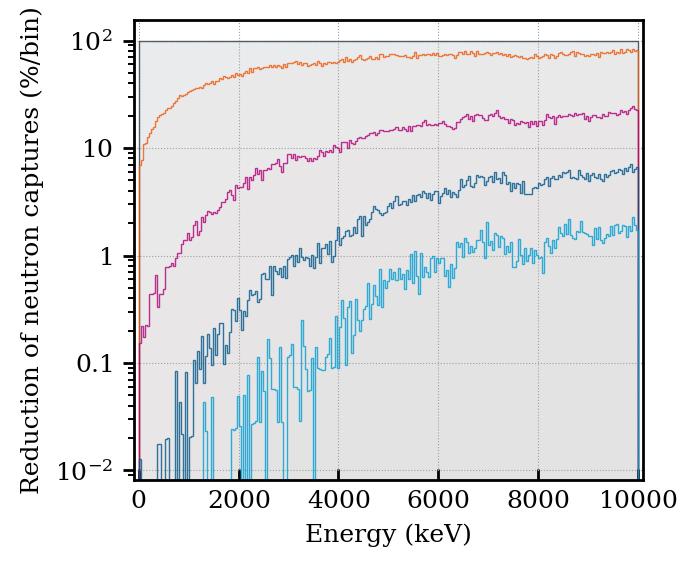

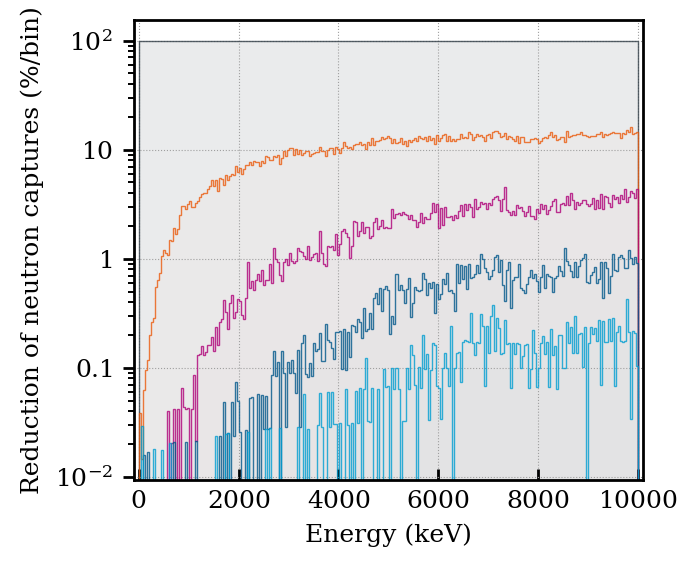

In [157]:
bins = np.linspace(0, 10000, 250)
colors = [color for color in xps.colors.keys() if color != 'graphit']

# Berechne bin_centers aus den bins
bin_centers = (bins[:-1] + bins[1:]) / 2

inverse = False

# Erstelle einen Plot pro Material
for i, mat in enumerate([poly_port, poly25_port]):    
    plt.hist(bin_centers, bins=bins, weights=unp.nominal_values(null_port) *100,
                histtype='step', alpha=0.8, linewidth=0.5, color = xps.colors['graphit']
                )
    plt.hist(bin_centers, bins=bins, weights=unp.nominal_values(null_port) *100,
                histtype='stepfilled', alpha=0.1, color = xps.colors['graphit'])
    for j, vals in enumerate(mat):
        # Verwende bin_centers für die x-Werte und bins für die bins
        if inverse:
            w = (100 - unp.nominal_values(vals) * 100) 
        else:
            w = unp.nominal_values(vals) * 100 
        plt.hist(bin_centers, bins=bins, weights=w,
                histtype='step', alpha=0.8, linewidth=0.5, color = xps.colors[colors[j]]
                )
        plt.hist(bin_centers, bins=bins, weights=w,
                histtype='stepfilled', alpha=0.01, color = xps.colors[colors[j]])

    # Diese Formatierung gehört AUSSERHALB der inneren Schleife, aber INNERHALB der äußeren
    plt.xlabel('Energy (keV)')
    plt.ylabel('Reduction of neutron captures (%/bin)')
    plt.yscale('log')
    b = 100
    plt.xlim(-b, 10000+b)
    plt.tick_params(axis='y', direction='out', which='both')
    plt.grid(True)
    
    # Speichere jeden Plot separat
    material_name = "Polyethylene" if i == 0 else "Polyethylene25"
    plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/all/NC_comparison_{material_name}.pdf", 
                bbox_inches='tight', dpi=300)
    plt.show()

## Flux


In [4]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/NoAbsorber/10cm/Flux.npz"

laenge= np.load(path, allow_pickle=True)['laenge']  # Speichere die Länge der Daten
bins = np.load(path, allow_pickle=True)['bins']
hist_vals = np.load(path, allow_pickle=True)['hist']



In [5]:
error_hist_vals = np.sqrt(hist_vals)
hist_vals_comb = unp.uarray(hist_vals, error_hist_vals)

hist_vals_comb_norm = hist_vals_comb / laenge


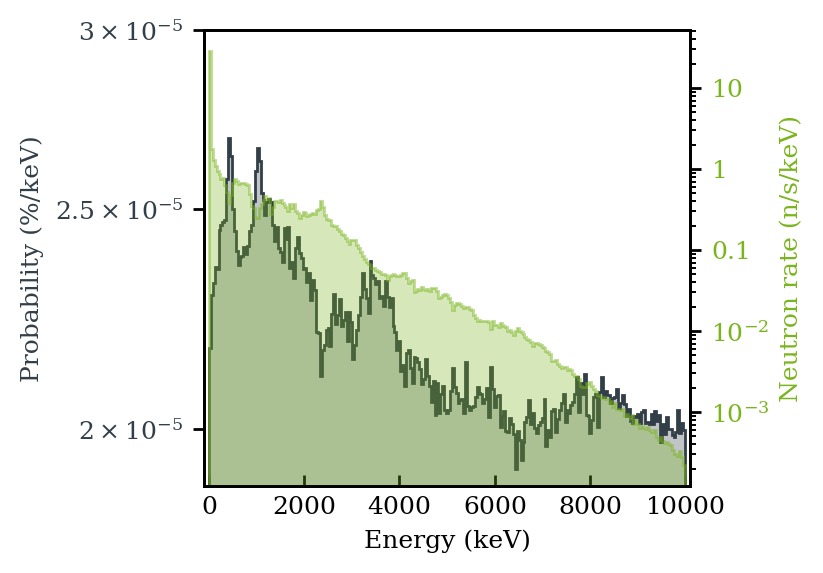

In [39]:
# ...existing code...

# Erstelle die erste y-Achse (links) für Probability
fig, ax1 = plt.subplots(figsize=(4, 2.75))

# Erstelle die zweite y-Achse (rechts) für Rates
ax2 = ax1.twinx()

ax2.hist(bins[:-1], bins=bins, weights=rates / bin_breite, histtype='step', 
         color=xps.colors['apfelgruen'], alpha=0.5, label='Rate')
ax2.hist(bins[:-1], bins=bins, weights=rates / bin_breite, histtype='stepfilled', 
         color=xps.colors['apfelgruen'], alpha=0.3)

ax2.set_ylabel('Neutron rate (n/s/keV)', color=xps.colors['apfelgruen'])
ax2.tick_params(axis='y', labelcolor=xps.colors['apfelgruen'])
ax2.set_yscale('log')

ax1.hist(bins[:-1], bins=bins, weights=unp.nominal_values(hist_vals_comb_norm) * 100 / bin_breite, histtype='step', color=xps.colors['graphit'])
ax1.hist(bins[:-1], bins=bins, weights=unp.nominal_values(hist_vals_comb_norm) * 100 / bin_breite, histtype='stepfilled', color=xps.colors['graphit'], alpha=0.3)

ax1.set_yscale('log')
ax1.set_xlabel('Energy (keV)')
ax1.set_ylabel('Probability (%/keV)', color=xps.colors['graphit'])
ax1.tick_params(axis='y', labelcolor=xps.colors['graphit'], direction='out')
y_ticks_left = np.array([2e-5, 2.5e-5, 3e-5])
ax1.set_yticks(y_ticks_left)


b=100
plt.xlim(-b, 10000+b)
plt.tick_params(axis='y', direction='out', which='both')
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/4_7e82d44/NoAbsorber/10cm/probAndRate.pdf")
plt.show()

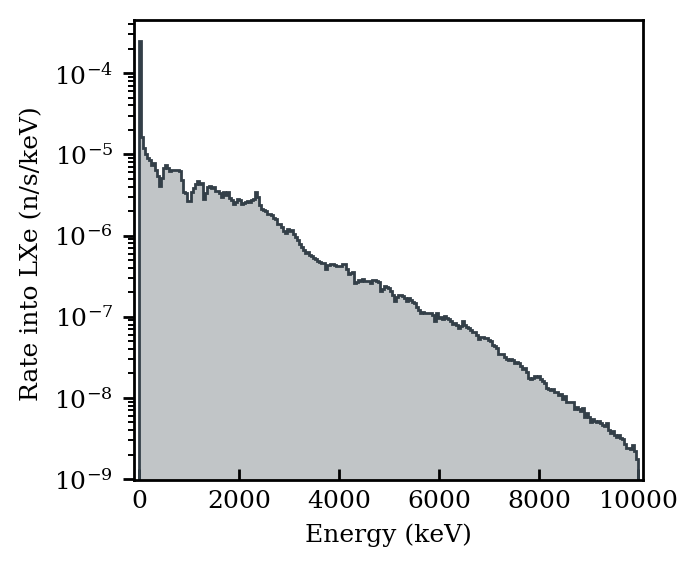

In [7]:
hist_vals_rate = hist_vals_comb_norm * rates_comb

plt.hist(bins[:-1], bins=bins, weights=unp.nominal_values(hist_vals_rate)/bin_breite , histtype='step', color=xps.colors['graphit'])
plt.hist(bins[:-1], bins=bins, weights=unp.nominal_values(hist_vals_rate)/bin_breite , histtype='stepfilled', color=xps.colors['graphit'], alpha=0.3)

plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel('Rate into LXe (n/s/keV) ')
b=100
plt.xlim(-b, 10000+b)
plt.tick_params(axis='y', direction='out', which='both')
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/4_7e82d44/NoAbsorber/10cm/rate.pdf")

In [8]:
sum(hist_vals_rate)

0.02351524107948526+/-7.788170445500947e-05

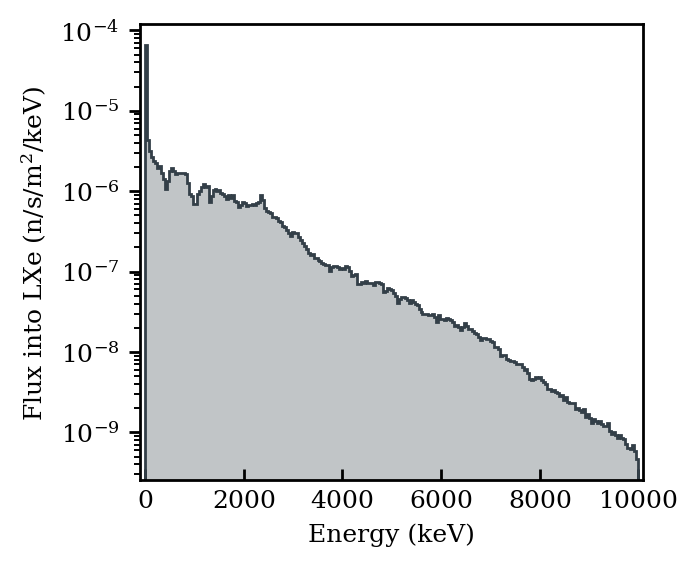

In [9]:
area = 0.46**2 * 6 * 3 # 6 Seiten, 3 würfel
hist_vals_flux = hist_vals_rate / area

plt.hist(bins[:-1], bins=bins, weights=unp.nominal_values(hist_vals_flux) / bin_breite , histtype='step', color=xps.colors['graphit'])
plt.hist(bins[:-1], bins=bins, weights=unp.nominal_values(hist_vals_flux) / bin_breite , histtype='stepfilled', color=xps.colors['graphit'], alpha=0.3)

plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel(r'Flux into LXe (n/s/m$^2$/keV) ')

b=100
plt.xlim(-b, 10000+b)
plt.tick_params(axis='y', direction='out', which='both')
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/4_7e82d44/NoAbsorber/10cm/Flux_NoAbsorber.pdf")
plt.show()

In [10]:
sum(hist_vals_flux)

0.006173923828892369+/-2.0447832507616432e-05

### Sep flux

In [11]:
# ...existing code...

path_Version = "4_7e82d44"
path_Material = "NoAbsorber"  # NoAbsorber
path_length = "10cm"

print(f"Konfiguration: {path_Version}, {path_Material}, {path_length}")

# Lade die gruppierten Save_y Daten
path_grouped = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/Flux_sep_cubes.npz"

if os.path.exists(path_grouped):
    print(f"Lade gruppierte Save_y Daten: {path_grouped}")
    
    # Lade die Daten
    laenge = np.load(path_grouped, allow_pickle=True)['laenge']
    bins = np.load(path_grouped, allow_pickle=True)['bins']
    hist_vals_group1 = np.load(path_grouped, allow_pickle=True)['hist_group1']  # Save_y < -240
    hist_vals_group2 = np.load(path_grouped, allow_pickle=True)['hist_group2']  # -240 <= Save_y <= 240
    hist_vals_group3 = np.load(path_grouped, allow_pickle=True)['hist_group3']  # Save_y > 240
    group_labels = np.load(path_grouped, allow_pickle=True)['group_labels']
    
    print(f"Geladene Gruppen:")
    print(f"  Gruppe 1 ({group_labels[0]}): {hist_vals_group1.sum()} Events")
    print(f"  Gruppe 2 ({group_labels[1]}): {hist_vals_group2.sum()} Events") 
    print(f"  Gruppe 3 ({group_labels[2]}): {hist_vals_group3.sum()} Events")
    print(f"  Gesamte simulierte Events: {laenge}")
    
else:
    print(f"Fehler: Datei {path_grouped} existiert nicht!")


Konfiguration: 4_7e82d44, NoAbsorber, 10cm
Lade gruppierte Save_y Daten: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/NoAbsorber/10cm/Flux_sep_cubes.npz
Geladene Gruppen:
  Gruppe 1 (Save_y < -240): 1489230.0 Events
  Gruppe 2 (-240 <= Save_y <= 240): 1435052.0 Events
  Gruppe 3 (Save_y > 240): 1373183.0 Events
  Gesamte simulierte Events: 1981323443


In [12]:
hist_vals_group1 = unp.uarray(hist_vals_group1, np.sqrt(hist_vals_group1))
hist_vals_group2 = unp.uarray(hist_vals_group2, np.sqrt(hist_vals_group2))
hist_vals_group3 = unp.uarray(hist_vals_group3, np.sqrt(hist_vals_group3))

In [13]:
hist_vals_group1_norm = hist_vals_group1 / laenge
hist_vals_group2_norm = hist_vals_group2 / laenge
hist_vals_group3_norm = hist_vals_group3 / laenge

hist_vals_group1_rate = hist_vals_group1_norm * rates_comb
hist_vals_group2_rate = hist_vals_group2_norm * rates_comb
hist_vals_group3_rate = hist_vals_group3_norm * rates_comb

area_small = 0.46**2 * 6 

hist_vals_group1_flux = hist_vals_group1_rate / area_small
hist_vals_group2_flux = hist_vals_group2_rate / area_small
hist_vals_group3_flux = hist_vals_group3_rate / area_small

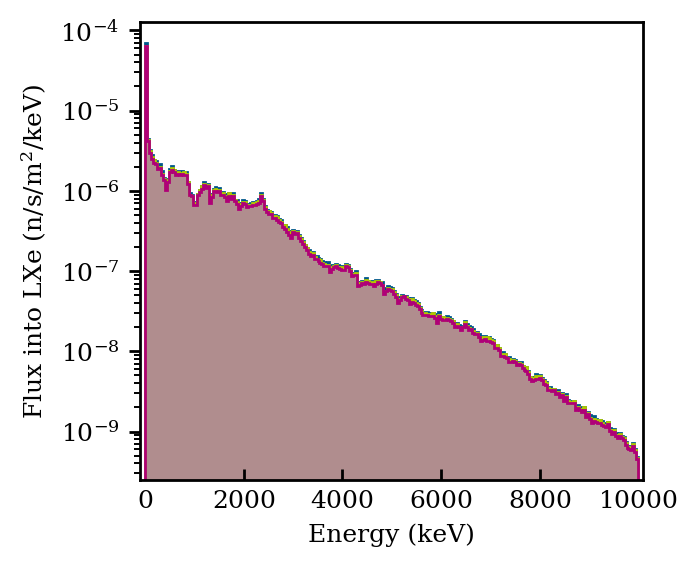

In [14]:
plt.hist(bins[:-1], bins=bins, weights=unp.nominal_values(hist_vals_group1_flux) / bin_breite, 
         histtype='step', 
         color=xps.colors['lapis'])
plt.hist(bins[:-1], bins=bins, weights=unp.nominal_values(hist_vals_group1_flux) / bin_breite, 
         histtype='stepfilled', alpha=0.3, color=xps.colors['lapis'])

plt.hist(bins[:-1], bins=bins, weights=unp.nominal_values(hist_vals_group2_flux) / bin_breite, 
         histtype='step', 
         color=xps.colors['peridot'])
plt.hist(bins[:-1], bins=bins, weights=unp.nominal_values(hist_vals_group2_flux) / bin_breite, 
         histtype='stepfilled', alpha=0.3, color=xps.colors['peridot'])

plt.hist(bins[:-1], bins=bins, weights=unp.nominal_values(hist_vals_group3_flux) / bin_breite, 
         histtype='step', 
         color=xps.colors['cassis'])
plt.hist(bins[:-1], bins=bins, weights=unp.nominal_values(hist_vals_group3_flux) / bin_breite, 
         histtype='stepfilled', alpha=0.3, color=xps.colors['cassis'])

plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel(r'Flux into LXe (n/s/m$^2$/keV)')

b=100
plt.xlim(-b, 10000+b)
plt.tick_params(axis='y', direction='out', which='both')
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/4_7e82d44/NoAbsorber/10cm/Flux_NoAbsorber_sepCubes.pdf")
plt.show()

In [15]:
r1 = sum(hist_vals_group1_flux) * 10000
r2 = sum(hist_vals_group2_flux) * 10000
r3 = sum(hist_vals_group3_flux) * 10000

r1, r2, r3, (1-r3/r1)*100

(64.6182956892327+/-0.3634025993660741,
 61.23407437299088+/-0.35076178278633613,
 59.36534480454741+/-0.3479868992046314,
 8.129200605890595+/-0.7462387166757821)

In [16]:
s1 = 0.5 + 0.23 + 3 + 0.20 + 2.5
s2 = 3 + 0.20 + 2.5
s3 = -0.5 - 0.23 + 3 + 0.20 + 2.5

s1, s2, s3

(6.43, 5.7, 4.970000000000001)

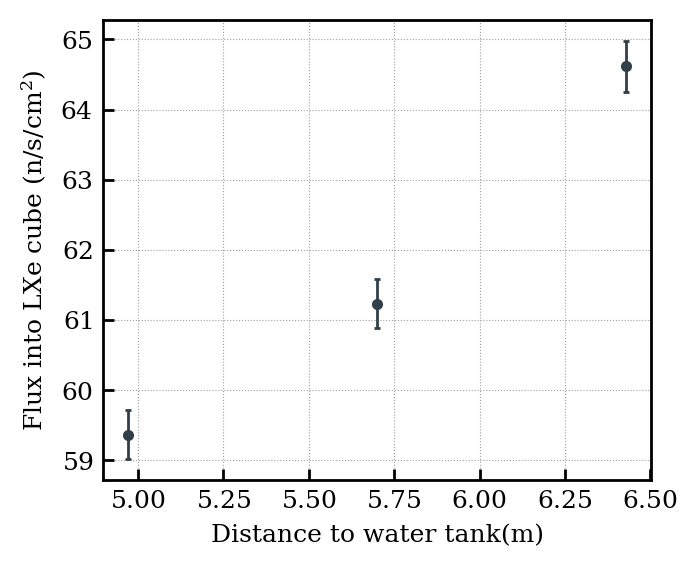

In [17]:
x = [s1, s2, s3]
y = [r1, r2, r3]

plt.errorbar(x, unp.nominal_values(y), yerr=unp.std_devs(y), fmt='o', color=xps.colors['graphit'])
plt.grid()
plt.xlabel('Distance to water tank(m)')
plt.ylabel(r'Flux into LXe cube (n/s/cm$^2$)')
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/4_7e82d44/NoAbsorber/10cm/Flux_NoAbsorber_sepCubes_vs_distance.pdf")

## Spatial

In [18]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/NoAbsorber/10cm/spatial_ncaptures.npz"

#hist_yx_vals = np.load(path, allow_pickle=True)['hist_yx_vals']  # Array von Histogrammen
#hist_yz_vals = np.load(path, allow_pickle=True)['hist_yz_vals']  # Array von Histogrammen
hist_xy_vals = np.load(path, allow_pickle=True)['hist_xy_vals']  # Array von Histogrammen
hist_xz_vals = np.load(path, allow_pickle=True)['hist_xz_vals']  # Array von Histogrammen

ranges = np.load(path, allow_pickle=True)['ranges']
bins_all = np.load(path, allow_pickle=True)['bins_all']
laenge = np.load(path, allow_pickle=True)['laenge']  # Speichere die Länge der Daten

# 5 cm slices

In [19]:
bin_breite_spatial = 500 / 100

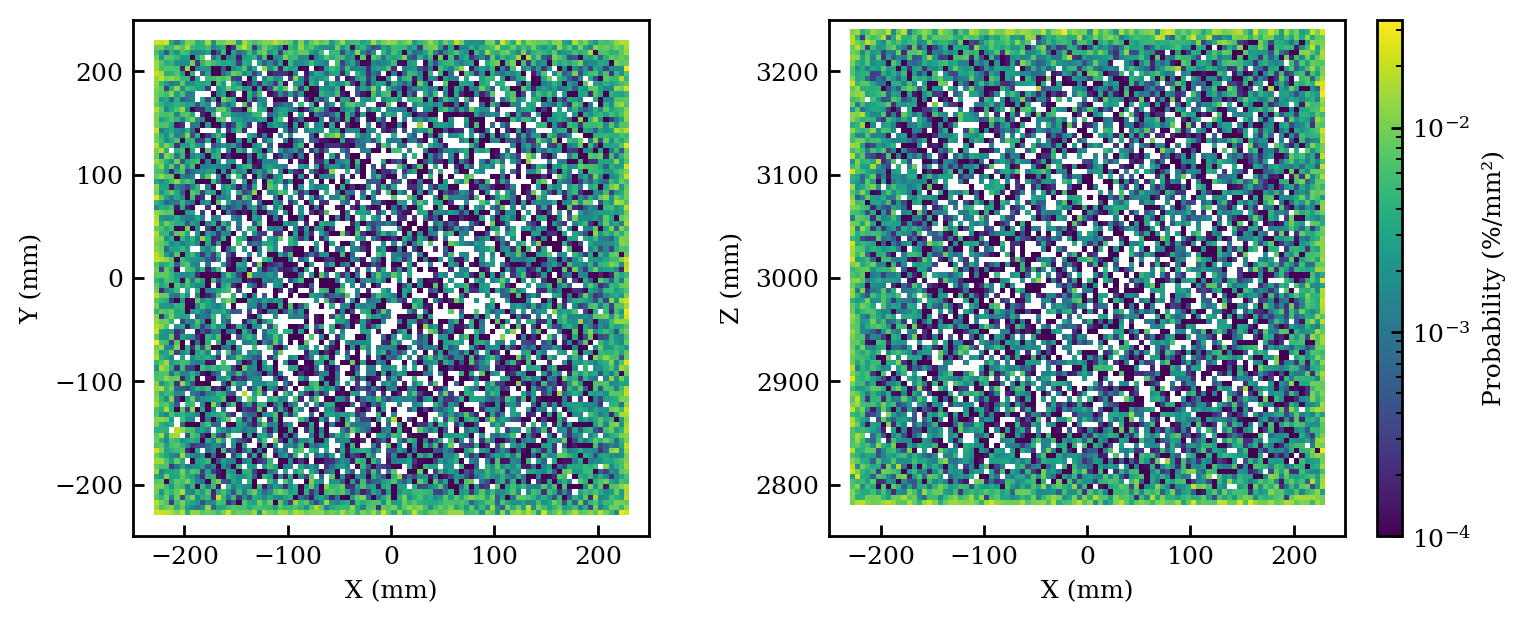

In [20]:
x_range, y_range, z_range = ranges
x_bins, y_bins, z_bins = bins_all

xy_proj = hist_xy_vals / hist_xy_vals.sum() * 100 / bin_breite_spatial  # Normalisiere die Projektion
xz_proj = hist_xz_vals / hist_xz_vals.sum() * 100 / bin_breite_spatial  # Normalisiere die Projektion

max_val_xy = xy_proj.max()
max_val_xz = xz_proj.max()
min_val_xy = xy_proj[xy_proj > 0].min()
min_val_xz = xz_proj[xz_proj > 0].min()
max_val = max(max_val_xy, max_val_xz)
min_val = min(min_val_xy, min_val_xz)

all_xy = hist_xy_vals.sum()
all_xz = hist_xz_vals.sum()

fig ,ax = plt.subplots(nrows = 1, ncols = 2, figsize=(7.5, 3))

aspect = 'auto'
aspect = 'equal'

norm = mpl.colors.LogNorm(vmin=1e-4, vmax=max_val) 
#norm = mpl.colors.Normalize(vmin=0, vmax=max_val)  # Use Normalize for linear scaling

ax[0].imshow(
    xy_proj.T,  
    extent=(y_range[0], y_range[1], x_range[0], x_range[1]),
    origin='lower',
    aspect=aspect,
    norm=norm
)
ax[0].set_xlabel('X (mm)')
ax[0].set_ylabel('Y (mm)')



# XZ-Projektion (Summe über y)
ax[1].imshow(
    xz_proj.view().T,
    extent=(y_range[0], y_range[1], z_range[0], z_range[1]),
    origin='lower',
    aspect=aspect,
    norm=norm
)
ax[1].set_xlabel('X (mm)')
ax[1].set_ylabel('Z (mm)')

fig.colorbar(ax[1].images[0], ax=ax[1], label='Probability (%/mm²)')
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/4_7e82d44/NoAbsorber/10cm/Spatial_dist_NC.pdf")
plt.show()

In [21]:
np.shape(xy_proj)

(100, 100)

In [23]:
sum(x_sumy), sum(x_sumz)

(np.float64(19.999999999999996), np.float64(19.999999999999996))

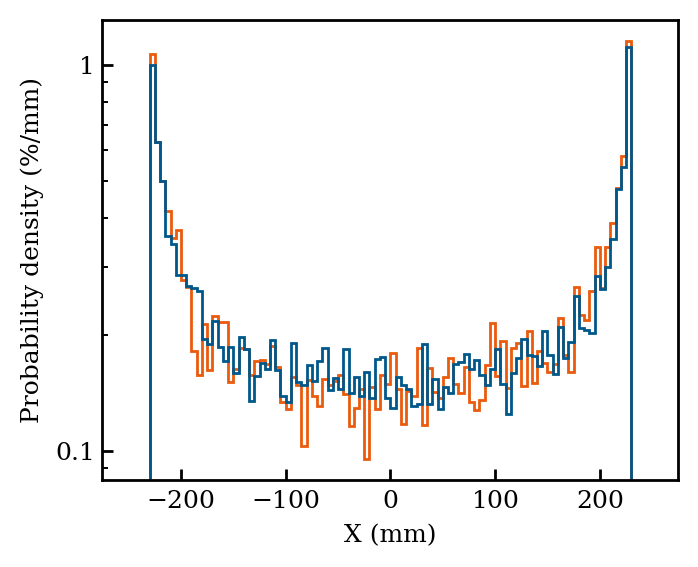

In [36]:
x_sumy = xy_proj.sum(axis=1)
x_sumz = xz_proj.sum(axis=1)

x = np.linspace(y_range[0], y_range[1], len(x_sumy))


plt.hist(x, bins=x_bins, weights=x_sumy , histtype='step', color=xps.colors['orange'], label='Summe über Y', linewidth = 1)
#plt.hist(x, bins=x_bins, weights=x_sumy , histtype='stepfilled', color=xps.colors['orange'], alpha=0.3)

plt.hist(x, bins=x_bins, weights=x_sumz , histtype='step', color=xps.colors['lapis'], label='Summe über Z', linewidth = 1)
#plt.hist(x, bins=x_bins, weights=x_sumz , histtype='stepfilled', color=xps.colors['lapis'], alpha=0.3)

plt.xlabel('X (mm)')
plt.ylabel('Probability density (%/mm)')
plt.yscale('log')
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/4_7e82d44/NoAbsorber/10cm/Spatial_dist_NC_x.pdf")
